# FSD Baseline

The goal is to observe the evolution of the electronics basline when no biased volatge is applied to the SiPMs.


In [1]:
%load_ext autoreload

%autoreload 2

from BaselineAnalysis import *


In [2]:
input_json='../data/test_baseline/reduced_2025Spring_BaselineRuns.json'
output_path='/Users/nsallin/develop/data/test_baseline/test_plots'

files = BaselineFiles(input_json=input_json, output_path=output_path, log_level='DEBUG')

2025-07-11 19:08:39,528 - INFO - set_log_level - Log level changed to DEBUG
2025-07-11 19:08:39,531 - INFO - __init__ - The input json file: ../data/test_baseline/reduced_2025Spring_BaselineRuns.json, 3 data files were found
2025-07-11 19:08:39,531 - INFO - __init__ - The ouput folder: /Users/nsallin/develop/data/test_baseline/test_plots


In [3]:
files.get_baselines()


2025-07-11 19:08:47,747 - DEBUG - __init__ - Processing /storage/data/LRS/test_baseline/light_flow/20250527_testBaseline/mpd_run_calib_rctl_108_p0.flow.hdf5
2025-07-11 19:08:47,748 - DEBUG - __init__ - The ouput folder: /Users/nsallin/develop/data/test_baseline/test_plots
2025-07-11 19:08:47,790 - DEBUG - __init__ - Number of events in the selection: 179
2025-07-11 19:08:47,794 - DEBUG - __init__ - Shape of the waveforms array: (179, 4, 64, 600)
2025-07-11 19:08:47,795 - DEBUG - compute_baselines - Computing the mean baselines of the file /storage/data/LRS/test_baseline/light_flow/20250527_testBaseline/mpd_run_calib_rctl_108_p0.flow.hdf5
2025-07-11 19:08:47,821 - DEBUG - get_baselines - shape of bl_wvfms (4, 64)
2025-07-11 19:08:47,822 - DEBUG - get_baselines - date: 2025-05-16
2025-07-11 19:08:47,826 - DEBUG - __init__ - Processing /storage/data/LRS/test_baseline/light_flow/20250527_testBaseline/mpd_run_calib_rctl_108_p1.flow.hdf5
2025-07-11 19:08:47,827 - DEBUG - __init__ - The ouput

2025-07-11 19:08:47,855 - DEBUG - __init__ - Number of events in the selection: 181
2025-07-11 19:08:47,856 - DEBUG - __init__ - Shape of the waveforms array: (181, 4, 64, 600)
2025-07-11 19:08:47,857 - DEBUG - compute_baselines - Computing the mean baselines of the file /storage/data/LRS/test_baseline/light_flow/20250527_testBaseline/mpd_run_calib_rctl_108_p1.flow.hdf5
2025-07-11 19:08:47,880 - DEBUG - get_baselines - shape of bl_wvfms (4, 64)
2025-07-11 19:08:47,881 - DEBUG - get_baselines - date: 2025-05-16
2025-07-11 19:08:47,883 - DEBUG - __init__ - Processing /storage/data/LRS/test_baseline/light_flow/20250603_testBaseline/mpd_run_dbg_rctl_052_dbg_evbld_p0.flow.hdf5
2025-07-11 19:08:47,884 - DEBUG - __init__ - The ouput folder: /Users/nsallin/develop/data/test_baseline/test_plots
2025-07-11 19:08:47,908 - DEBUG - __init__ - Number of events in the selection: 179
2025-07-11 19:08:47,909 - DEBUG - __init__ - Shape of the waveforms array: (179, 4, 64, 600)
2025-07-11 19:08:47,909 - 

In [4]:
files.fileIDs

array(['2025-05-16', '2025-05-16', '2025-06-03'], dtype='<U10')

In [5]:
files.baselines[:,1,1]


array([391.41217877, 391.45709024, 390.74629423])

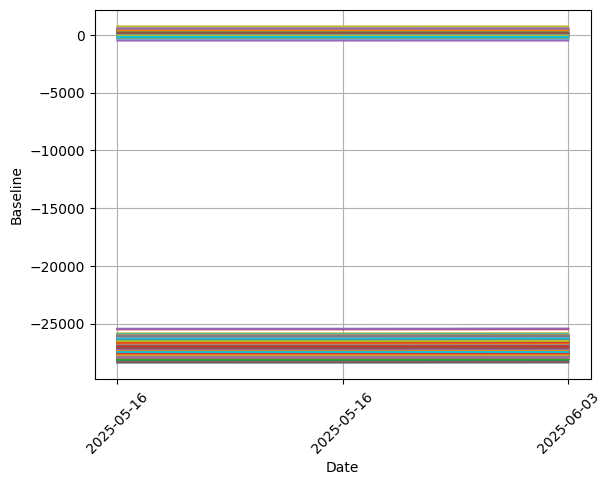

In [6]:
# Compute the x-axis coordinate
x = np.arange(0, len(files.fileIDs))

# Setup the plot
fig = plt.figure()#figsize=[12.8, 4.8])
ax = fig.subplots()

ax.set_xlabel('Date')
ax.set_ylabel('Baseline')
ax.grid(True)

inactive_chan = [30, 31, 62, 63]

for i_adc in range(4):
    for j_chan in range(64):
        if j_chan in inactive_chan:
            continue
        ax.plot(x, files.baselines[:,i_adc, j_chan])#, label=f'Event {event}, ADC {adc}, Chan. {chan}', marker='.', ls='')

ax.set_xticks(range(len(files.fileIDs)), labels=files.fileIDs, rotation=45)

fig.show()